**import des bibliotheques**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

**extraction et chargement des fichiers**

In [5]:
import zipfile

with zipfile.ZipFile("data/in_out_time.zip", "r") as zip_ref:
    zip_ref.extractall("in_out_time")

In [6]:
in_time = pd.read_csv("in_out_time/in_time.csv")
out_time = pd.read_csv("in_out_time/out_time.csv")

# Aperçu
in_time.head()
out_time.head()

,Unnamed: 0,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07,2015-01-08,2015-01-09,2015-01-12,2015-01-13,...,2015-12-18,2015-12-21,2015-12-22,2015-12-23,2015-12-24,2015-12-25,2015-12-28,2015-12-29,2015-12-30,2015-12-31
0,1,NaN,2015-01-02 16:56:15,2015-01-05 17:20:11,2015-01-06 17:19:05,2015-01-07 16:34:55,2015-01-08 17:08:32,2015-01-09 17:38:29,2015-01-12 16:58:39,2015-01-13 18:02:58,...,NaN,2015-12-21 17:15:50,2015-12-22 17:27:51,2015-12-23 16:44:44,2015-12-24 17:47:22,NaN,2015-12-28 18:00:07,2015-12-29 17:22:30,2015-12-30 17:40:56,2015-12-31 17:17:33
1,2,NaN,2015-01-02 18:22:17,2015-01-05 17:48:22,NaN,2015-01-07 17:09:06,2015-01-08 17:34:04,2015-01-09 16:52:29,2015-01-12 17:36:48,2015-01-13 18:00:13,...,2015-12-18 18:31:28,2015-12-21 17:34:16,2015-12-22 18:16:35,2015-12-23 17:38:18,NaN,NaN,2015-12-28 17:08:38,2015-12-29 17:54:46,2015-12-30 18:31:35,2015-12-31 17:40:58
2,3,NaN,2015-01-02 16:59:14,2015-01-05 17:06:46,2015-01-06 16:38:32,2015-01-07 16:33:21,2015-01-08 17:24:22,2015-01-09 16:57:30,2015-01-12 17:28:54,2015-01-13 17:21:25,...,2015-12-18 17:02:23,2015-12-21 17:20:17,2015-12-22 16:32:50,2015-12-23 16:59:43,2015-12-24 16:58:25,NaN,2015-12-28 16:43:31,2015-12-29 17:09:56,2015-12-30 17:06:25,2015-12-31 17:15:50
3,4,NaN,2015-01-02 17:25:24,2015-01-05 17:14:03,2015-01-06 17:07:42,2015-01-07 16:32:40,2015-01-08 16:53:11,2015-01-09 17:19:47,2015-01-12 17:13:37,2015-01-13 17:11:45,...,2015-12-18 17:55:23,2015-12-21 16:49:09,2015-12-22 17:24:00,2015-12-23 17:36:35,2015-12-24 16:48:21,NaN,2015-12-28 17:19:34,2015-12-29 16:58:16,2015-12-30 17:40:11,2015-12-31 17:09:14
4,5,NaN,2015-01-02 18:31:37,2015-01-05 17:49:15,2015-01-06 17:26:25,2015-01-07 17:37:59,2015-01-08 17:59:28,2015-01-09 17:44:08,2015-01-12 18:51:21,2015-01-13 18:14:58,...,2015-12-18 17:52:48,2015-12-21 17:43:35,2015-12-22 18:07:57,2015-12-23 18:00:49,2015-12-24 17:59:22,NaN,2015-12-28 17:44:59,2015-12-29 18:47:00,2015-12-30 17:15:33,2015-12-31 17:42:14


In [7]:
# Aperçu
in_time.info()
out_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, Unnamed: 0 to 2015-12-31
dtypes: float64(12), int64(1), object(249)
memory usage: 8.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Columns: 262 entries, Unnamed: 0 to 2015-12-31
dtypes: float64(12), int64(1), object(249)
memory usage: 8.8+ MB


**Visualisation des valeurs manquantes**

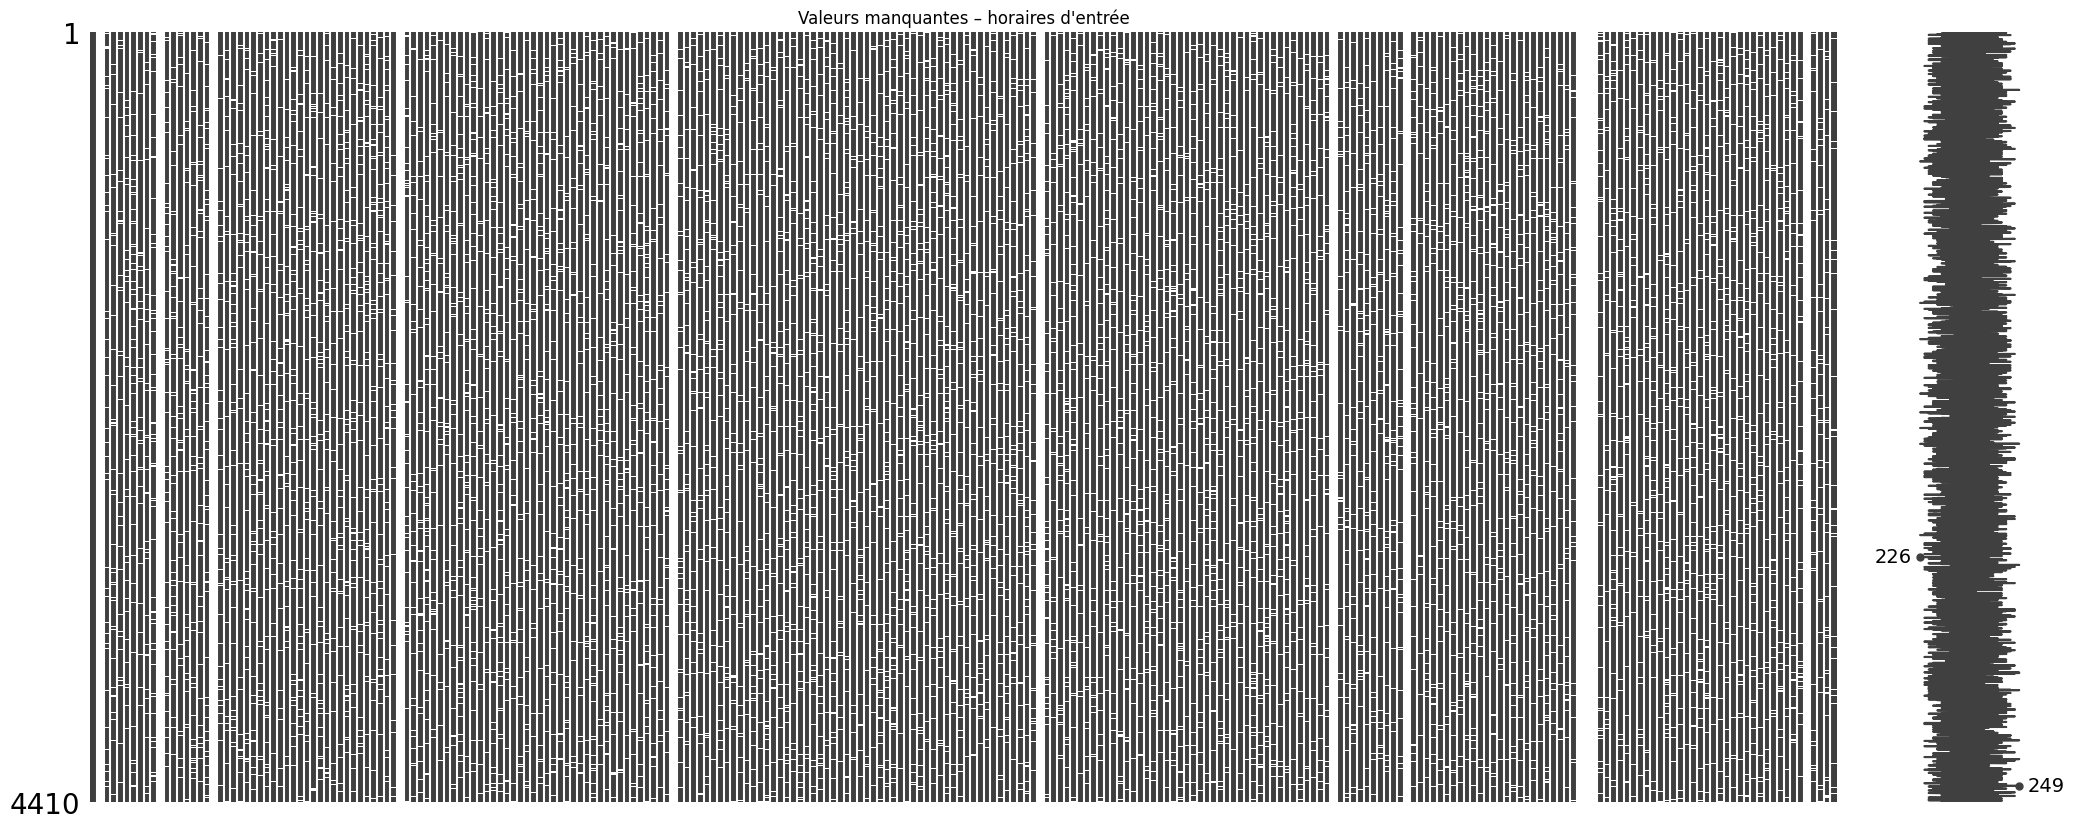

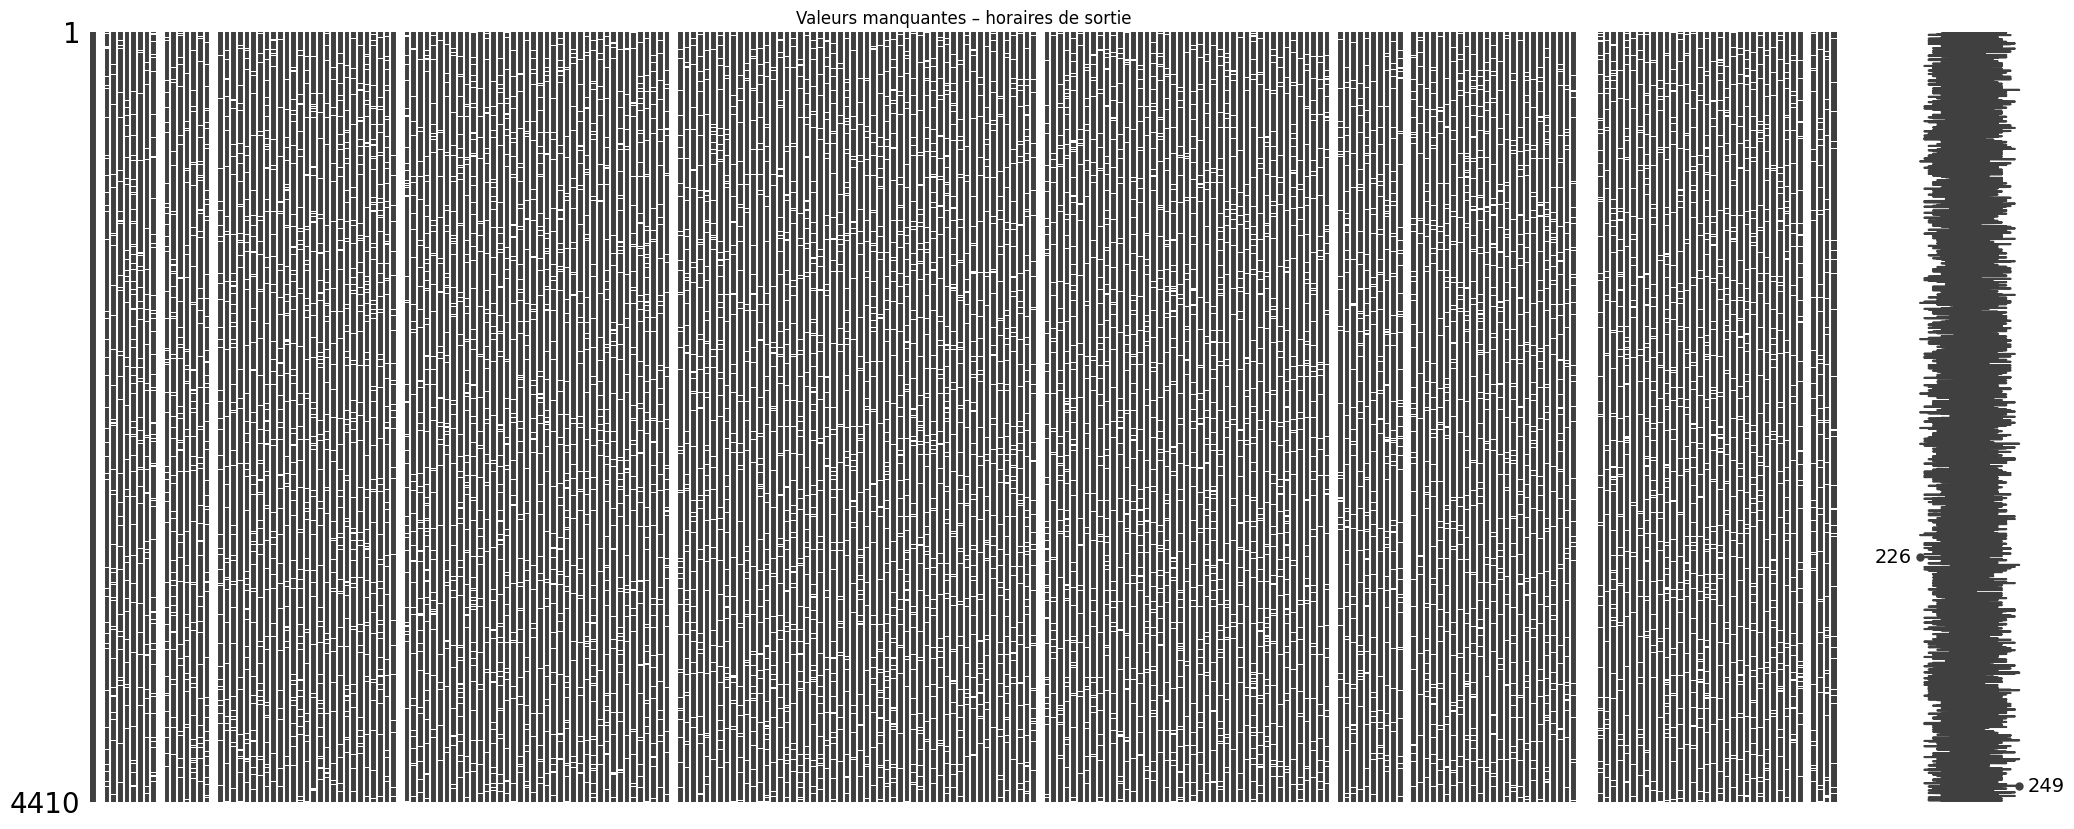

In [9]:
msno.matrix(in_time)
plt.title("Valeurs manquantes – horaires d'entrée")
plt.show()

msno.matrix(out_time)
plt.title("Valeurs manquantes – horaires de sortie")
plt.show()

In [16]:
in_time.isnull().sum()
out_time.isnull().sum()

Unnamed: 0       0
2015-01-01    4410
2015-01-02     209
2015-01-05     206
2015-01-06     228
              ... 
2015-12-25    4410
2015-12-28     234
2015-12-29     230
2015-12-30     265
2015-12-31     213
Length: 262, dtype: int64

**préparation des données horaires**

conversion des dates et heures

In [18]:
in_time.columns

Index(['Unnamed: 0', '2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06',
       '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
       ...
       '2015-12-18', '2015-12-21', '2015-12-22', '2015-12-23', '2015-12-24',
       '2015-12-25', '2015-12-28', '2015-12-29', '2015-12-30', '2015-12-31'],
      dtype='object', length=262)

In [19]:
out_time.columns

Index(['Unnamed: 0', '2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06',
       '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
       ...
       '2015-12-18', '2015-12-21', '2015-12-22', '2015-12-23', '2015-12-24',
       '2015-12-25', '2015-12-28', '2015-12-29', '2015-12-30', '2015-12-31'],
      dtype='object', length=262)

renommer la colonne "Unnamed par EmployeeID"

In [20]:
in_time.rename(columns={"Unnamed: 0": "EmployeeID"}, inplace=True)
out_time.rename(columns={"Unnamed: 0": "EmployeeID"}, inplace=True)


Passer du format large → format long ()

In [25]:
in_time_long = in_time.melt(
    id_vars="EmployeeID",
    var_name="Date",
    value_name="InTime"
)

In [26]:
out_time_long = out_time.melt(
    id_vars="EmployeeID",
    var_name="Date",
    value_name="OutTime"
)

Les fichiers d’horaires sont fournis sous un format large issu directement du système de badgeuse, où chaque colonne représente une date et chaque cellule un horodatage.
Afin de permettre l’analyse temporelle, le calcul des durées de travail et la gestion des valeurs manquantes, les données ont été transformées vers un format long, dans lequel chaque ligne correspond à un employé et une date donnée.

conversion des types : NA devient NAN

In [23]:
in_time_long["Date"] = pd.to_datetime(in_time_long["Date"])
in_time_long["InTime"] = pd.to_datetime(in_time_long["InTime"], errors="coerce")

out_time_long["Date"] = pd.to_datetime(out_time_long["Date"])
out_time_long["OutTime"] = pd.to_datetime(out_time_long["OutTime"], errors="coerce")

In [29]:
in_time_long.head(15)


,EmployeeID,Date,InTime
0,1,2015-01-01,NaN
1,2,2015-01-01,NaN
2,3,2015-01-01,NaN
3,4,2015-01-01,NaN
4,5,2015-01-01,NaN
5,6,2015-01-01,NaN
6,7,2015-01-01,NaN
7,8,2015-01-01,NaN
8,9,2015-01-01,NaN
9,10,2015-01-01,NaN


In [30]:
in_time_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1151010 entries, 0 to 1151009
Data columns (total 3 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   EmployeeID  1151010 non-null  int64 
 1   Date        1151010 non-null  object
 2   InTime      1041930 non-null  object
dtypes: int64(1), object(2)
memory usage: 26.3+ MB


In [31]:
in_time_long.dropna(subset=["InTime"]).head()


,EmployeeID,Date,InTime
4410,1,2015-01-02,2015-01-02 09:43:45
4411,2,2015-01-02,2015-01-02 10:15:44
4412,3,2015-01-02,2015-01-02 10:17:41
4413,4,2015-01-02,2015-01-02 10:05:06
4414,5,2015-01-02,2015-01-02 10:28:17


In [32]:
out_time_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1151010 entries, 0 to 1151009
Data columns (total 3 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   EmployeeID  1151010 non-null  int64 
 1   Date        1151010 non-null  object
 2   OutTime     1041930 non-null  object
dtypes: int64(1), object(2)
memory usage: 26.3+ MB


Après transformation des données de badgeage en format long, chaque ligne correspond à un employé pour une date donnée. La colonne InTime indique l’heure exacte d’arrivée au poste, tandis que la colonne Date permet de structurer l’analyse journalière. Cette organisation facilite les analyses temporelles et le calcul d’indicateurs liés au temps de travail.

**calcul des indicateurs temporels**

**1 - fusionner les heures d'entrée et de sortie**

In [33]:
time_df = pd.merge(in_time_long, out_time_long, on=["EmployeeID", "Date"], how="outer")


how="outer" pour ne pas perdre les lignes avec des valeurs manquantes (absences)

Le DataFrame time_df contient désormais :

| EmployeeID | Date | InTime | OutTime |

**2 -Calculer les heures travaillées** 

In [34]:
# Convertir en datetime si ce n'est pas déjà fait
time_df["InTime"] = pd.to_datetime(time_df["InTime"], errors="coerce")
time_df["OutTime"] = pd.to_datetime(time_df["OutTime"], errors="coerce")

# Calculer la durée de travail
time_df["WorkDuration"] = (time_df["OutTime"] - time_df["InTime"]).dt.total_seconds() / 3600  # en heures


**3 - gestion des valeurs manquantes**

In [ ]:
time_df.isna().sum()#identifier les absences ou retard

EmployeeID           0
Date                 0
InTime          109080
OutTime         109080
WorkDuration    109080
dtype: int64

In [36]:
time_df["WorkDuration"].fillna(0, inplace=True)#remplacer les absences par 0 heure de travail

C:\Users\HP\AppData\Local\Temp\ipykernel_1044\1310105993.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  time_df["WorkDuration"].fillna(0, inplace=True)#remplacer les absences par 0 heure de travail


**4- créer des indicateurs**

- longues journées: 
 Supposons que longue journée = >9 heures

In [37]:
time_df["LongDay"] = time_df["WorkDuration"] > 9

- absences répétées  

In [38]:
absence_summary = time_df.groupby("EmployeeID")["WorkDuration"].apply(lambda x: (x==0).sum()).reset_index()
absence_summary.rename(columns={"WorkDuration": "AbsenceDays"}, inplace=True)


**5- Visualition**

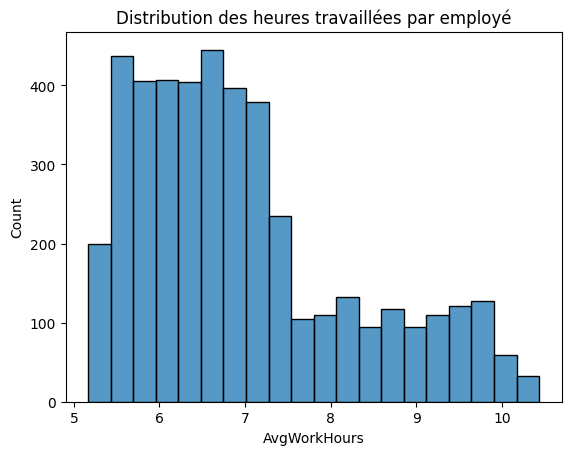

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

employee_summary = time_df.groupby("EmployeeID").agg(
    AvgWorkHours=("WorkDuration", "mean"),
    TotalLongDays=("LongDay", "sum"),
    TotalAbsenceDays=("WorkDuration", lambda x: (x==0).sum())
).reset_index()

sns.histplot(employee_summary["AvgWorkHours"], bins=20)
plt.title("Distribution des heures travaillées par employé")
plt.show()

L’histogramme de la moyenne des heures travaillées par employé montre une concentration autour de la durée légale de travail

In [42]:
time_df["Absent"] = time_df["WorkDuration"] == 0

In [43]:
absence_per_employee = (
    time_df.groupby("EmployeeID")["Absent"]
    .sum()
    .reset_index(name="AbsenceDays")
)

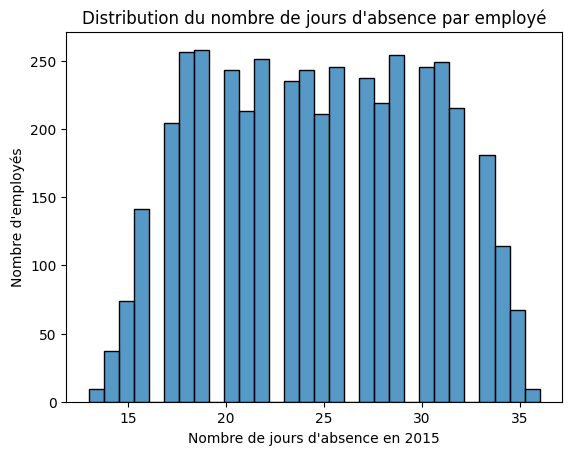

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(absence_per_employee["AbsenceDays"], bins=30)
plt.title("Distribution du nombre de jours d'absence par employé")
plt.xlabel("Nombre de jours d'absence en 2015")
plt.ylabel("Nombre d'employés")
plt.show()